### Credit Risk Scoring Project

#### Data Cleaning and Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import export_text
import xgboost as xgb
import re

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv')

In [3]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df['status'] = df.status.map({1: 'ok', 2: 'default', 0: 'unk'})

In [6]:
df.head

<bound method NDFrame.head of        status  seniority  home  time  age  marital  records  job  expenses  \
0          ok          9     1    60   30        2        1    3        73   
1          ok         17     1    60   58        3        1    1        48   
2     default         10     2    36   46        2        2    3        90   
3          ok          0     1    60   24        1        1    1        63   
4          ok          0     1    36   26        1        1    1        46   
...       ...        ...   ...   ...  ...      ...      ...  ...       ...   
4450  default          1     1    60   39        2        1    1        69   
4451       ok         22     2    60   46        2        1    1        60   
4452  default          0     2    24   37        2        1    2        60   
4453       ok          0     1    48   23        1        1    3        49   
4454       ok          5     2    60   32        2        1    3        60   

      income  assets  debt  amoun

In [7]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [8]:
df.describe().round(2)

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.00,4455.00,4455.00,4455.00,4455.00,4455.00,4455.00,4455.00,4455.00
mean,7.99,46.44,37.08,55.57,763316.99,1060340.81,404381.96,1039.02,1462.88
std,8.17,14.66,10.98,19.52,8703625.26,10217568.67,6344253.40,474.54,628.09
min,0.00,6.00,18.00,35.00,0.00,0.00,0.00,100.00,105.00
25%,2.00,36.00,28.00,35.00,80.00,0.00,0.00,700.00,1117.50
50%,5.00,48.00,36.00,51.00,120.00,3500.00,0.00,1000.00,1400.00
75%,12.00,60.00,45.00,72.00,166.00,6000.00,0.00,1300.00,1692.00
max,48.00,72.00,68.00,180.00,99999999.00,99999999.00,99999999.00,5000.00,11140.00


In [9]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(df[c].max(), np.nan)

In [10]:
df.describe().round(2)

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.00,4455.00,4455.00,4455.00,4421.00,4408.00,4437.00,4455.00,4455.00
mean,7.99,46.44,37.08,55.57,130.57,5403.43,342.95,1039.02,1462.88
std,8.17,14.66,10.98,19.52,86.37,11573.16,1245.86,474.54,628.09
min,0.00,6.00,18.00,35.00,0.00,0.00,0.00,100.00,105.00
25%,2.00,36.00,28.00,35.00,80.00,0.00,0.00,700.00,1117.50
50%,5.00,48.00,36.00,51.00,120.00,3000.00,0.00,1000.00,1400.00
75%,12.00,60.00,45.00,72.00,165.00,6000.00,0.00,1300.00,1692.00
max,48.00,72.00,68.00,180.00,959.00,300000.00,30000.00,5000.00,11140.00


In [11]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [12]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [13]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [14]:
y_train = (df_train.status == 'default').astype(int)
y_val = (df_val.status == 'default').astype(int)
y_test = (df_test.status == 'default').astype(int)

In [15]:
del df_train['status']
del df_val['status']
del df_test['status']

In [16]:
df.describe().round(2)

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.00,4454.00,4454.00,4454.00,4420.00,4407.00,4436.00,4454.00,4454.00
mean,7.99,46.44,37.08,55.57,130.56,5403.98,343.03,1038.92,1462.78
std,8.17,14.66,10.98,19.52,86.38,11574.42,1245.99,474.55,628.13
min,0.00,6.00,18.00,35.00,0.00,0.00,0.00,100.00,105.00
25%,2.00,36.00,28.00,35.00,80.00,0.00,0.00,700.00,1117.25
50%,5.00,48.00,36.00,51.00,120.00,3000.00,0.00,1000.00,1400.00
75%,12.00,60.00,45.00,72.00,165.00,6000.00,0.00,1300.00,1691.50
max,48.00,72.00,68.00,180.00,959.00,300000.00,30000.00,5000.00,11140.00


#### Decision Trees

In [17]:
train_dict = df_train.fillna(0).to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

In [18]:
dv.feature_names_

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [19]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
val_dict = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)

In [21]:
y_val_pred = dt.predict_proba(X_val)

In [22]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_val, y_val_pred[:, 1])

0.65360490179458

In [23]:
y_train_pred = dt.predict_proba(X_train)
roc_auc_score(y_train, y_train_pred[:, 1])

1.0

#### Controling the depth of decision tree

In [24]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [25]:
y_val_pred = dt.predict_proba(X_val)
roc_auc_score(y_val, y_val_pred[:, 1])

0.7389079944782155

In [26]:
y_train_pred = dt.predict_proba(X_train)
roc_auc_score(y_train, y_train_pred[:, 1])

0.7761016984958594

In [27]:
max_roc_auc = 0
for max_depth in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    y_val_pred = dt.predict_proba(X_val)
    print(f"max_depth={max_depth}, roc_auc={roc_auc_score(y_val, y_val_pred[:, 1])}")
    y_train_pred = dt.predict_proba(X_train)
    print(f"max_depth={max_depth}, train_roc_auc={roc_auc_score(y_train, y_train_pred[:, 1])}")
    if roc_auc_score(y_val, y_val_pred[:, 1]) > max_roc_auc:
        max_roc_auc = roc_auc_score(y_val, y_val_pred[:, 1])
        best_max_depth = max_depth
print(f"Best max_depth: {best_max_depth}, Best roc_auc (val): {max_roc_auc}")


max_depth=1, roc_auc=0.6058644740984719
max_depth=1, train_roc_auc=0.6282660131823559
max_depth=2, roc_auc=0.6685264343319367
max_depth=2, train_roc_auc=0.7054989859726213
max_depth=3, roc_auc=0.7389079944782155
max_depth=3, train_roc_auc=0.7761016984958594
max_depth=4, roc_auc=0.7612827250490422
max_depth=4, train_roc_auc=0.8164293560926146
max_depth=5, roc_auc=0.7664957254607541
max_depth=5, train_roc_auc=0.8433781899611289
max_depth=6, roc_auc=0.7496064517691506
max_depth=6, train_roc_auc=0.8745461523294462
max_depth=7, roc_auc=0.7486831270736966
max_depth=7, train_roc_auc=0.8995915723057856
max_depth=8, roc_auc=0.7363499309776949
max_depth=8, train_roc_auc=0.9240532223536703
max_depth=9, roc_auc=0.7107511322079872
max_depth=9, train_roc_auc=0.9475779533547406
max_depth=10, roc_auc=0.6948548109757575
max_depth=10, train_roc_auc=0.9635031125007042
Best max_depth: 5, Best roc_auc (val): 0.7664957254607541


In [28]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
tree_rules = export_text(dt, feature_names=dv.get_feature_names_out())
print(tree_rules)

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- seniority <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- seniority >  0.50
|   |   |   |   |--- income <= 50.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- income >  50.50
|   |   |   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- assets <= 8250.00
|   |   |   |   |--- job=fixed <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- job=fixed >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  8250.00
|   |   |   |   |--- income <= 132.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- income >  132.50
|   |   |   |   |   |--- class: 0
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- assets <= 4500.00
|   |   |   |   |--- seniority <= 12.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- seniority >  12.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  4500.00
|   |   |   

#### Decision Tree Learning Algorithm

In [29]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [30]:
df_example.sort_values(by='assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [31]:
Ts = [2000, 3000, 4000, 5000, 8000]

In [32]:
for T in Ts:
    df_left = df_example[df_example['assets'] <= T]
    df_right = df_example[df_example['assets'] > T]
    print(f"Threshold: {T}")
    print("Left split:")
    print(df_left)
    print(df_left.status.value_counts(normalize=True))
    print("Right split:")
    print(df_right)
    print(df_right.status.value_counts(normalize=True))
    print()


Threshold: 2000
Left split:
   assets   status
1    2000  default
2       0  default
status
default    1.0
Name: proportion, dtype: float64
Right split:
   assets   status
0    8000  default
3    5000       ok
4    5000       ok
5    4000       ok
6    9000       ok
7    3000  default
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

Threshold: 3000
Left split:
   assets   status
1    2000  default
2       0  default
7    3000  default
status
default    1.0
Name: proportion, dtype: float64
Right split:
   assets   status
0    8000  default
3    5000       ok
4    5000       ok
5    4000       ok
6    9000       ok
status
ok         0.8
default    0.2
Name: proportion, dtype: float64

Threshold: 4000
Left split:
   assets   status
1    2000  default
2       0  default
5    4000       ok
7    3000  default
status
default    0.75
ok         0.25
Name: proportion, dtype: float64
Right split:
   assets   status
0    8000  default
3    5000       ok
4    5000  

In [33]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000,  500, 'ok'],
    [3000, 2000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example



,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [34]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [35]:
for feature, Ts in thresholds.items():
    for T in Ts:
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]
        print(f"Feature: {feature}, Threshold: {T}")
        print("Left split:")
        print(df_left)
        print(df_left.status.value_counts(normalize=True))
        print("Right split:")
        print(df_right)
        print(df_right.status.value_counts(normalize=True))
        print()

Feature: assets, Threshold: 0
Left split:
   assets  debt   status
2       0  1000  default
status
default    1.0
Name: proportion, dtype: float64
Right split:
   assets  debt   status
0    8000  3000  default
1    2000  1000  default
3    5000  1000       ok
4    5000  1000       ok
5    4000  1000       ok
6    9000   500       ok
7    3000  2000  default
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

Feature: assets, Threshold: 2000
Left split:
   assets  debt   status
1    2000  1000  default
2       0  1000  default
status
default    1.0
Name: proportion, dtype: float64
Right split:
   assets  debt   status
0    8000  3000  default
3    5000  1000       ok
4    5000  1000       ok
5    4000  1000       ok
6    9000   500       ok
7    3000  2000  default
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

Feature: assets, Threshold: 3000
Left split:
   assets  debt   status
1    2000  1000  default
2       0  1000  def

#### Decision trees parameter tuning

In [36]:
df_scores = pd.DataFrame(columns=["max_depth", "min_samples_leaf", "roc_auc"])
max_roc_auc = 0
best_params = None
for d in [4, 5, 6]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf = s)
        dt.fit(X_train, y_train)
        y_val_pred = dt.predict_proba(X_val)
        print(f"max_depth={d}, min_samples_leaf={s}, roc_auc={roc_auc_score(y_val, y_val_pred[:, 1])}")
        y_train_pred = dt.predict_proba(X_train)
        print(f"max_depth={d}, min_samples_leaf={s}, train_roc_auc={roc_auc_score(y_train, y_train_pred[:, 1])}")
        df_scores = pd.concat([df_scores, pd.DataFrame([{"max_depth": d, "min_samples_leaf": s, "roc_auc": roc_auc_score(y_val, y_val_pred[:, 1])}])], ignore_index=True)
        if roc_auc_score(y_val, y_val_pred[:, 1]) > max_roc_auc:
            max_roc_auc = roc_auc_score(y_val, y_val_pred[:, 1])
            best_params = {"max_depth": d, "min_samples_leaf": s}
print(f"Best max_roc_auc: {max_roc_auc}")
print(f"Best params: {best_params}")

max_depth=4, min_samples_leaf=1, roc_auc=0.7612827250490422
max_depth=4, min_samples_leaf=1, train_roc_auc=0.8164293560926146
max_depth=4, min_samples_leaf=2, roc_auc=0.7612827250490422
max_depth=4, min_samples_leaf=2, train_roc_auc=0.8164293560926146
max_depth=4, min_samples_leaf=5, roc_auc=0.7612827250490422
max_depth=4, min_samples_leaf=5, train_roc_auc=0.8164293560926146
max_depth=4, min_samples_leaf=10, roc_auc=0.7612827250490422
max_depth=4, min_samples_leaf=10, train_roc_auc=0.8164293560926146
max_depth=4, min_samples_leaf=15, roc_auc=0.7637257513743916
max_depth=4, min_samples_leaf=15, train_roc_auc=0.817233888231649
max_depth=4, min_samples_leaf=20, roc_auc=0.760910367876777
max_depth=4, min_samples_leaf=20, train_roc_auc=0.816833206579911
max_depth=4, min_samples_leaf=100, roc_auc=0.7559365236976581
max_depth=4, min_samples_leaf=100, train_roc_auc=0.8031582727733648
max_depth=4, min_samples_leaf=200, roc_auc=0.7472602988544719
max_depth=4, min_samples_leaf=200, train_roc_auc=

In [37]:
df_scores

,max_depth,min_samples_leaf,roc_auc
0,4,1,0.761283
1,4,2,0.761283
2,4,5,0.761283
3,4,10,0.761283
4,4,15,0.763726
5,4,20,0.76091
6,4,100,0.755937
7,4,200,0.74726
8,4,500,0.679842
9,5,1,0.766938


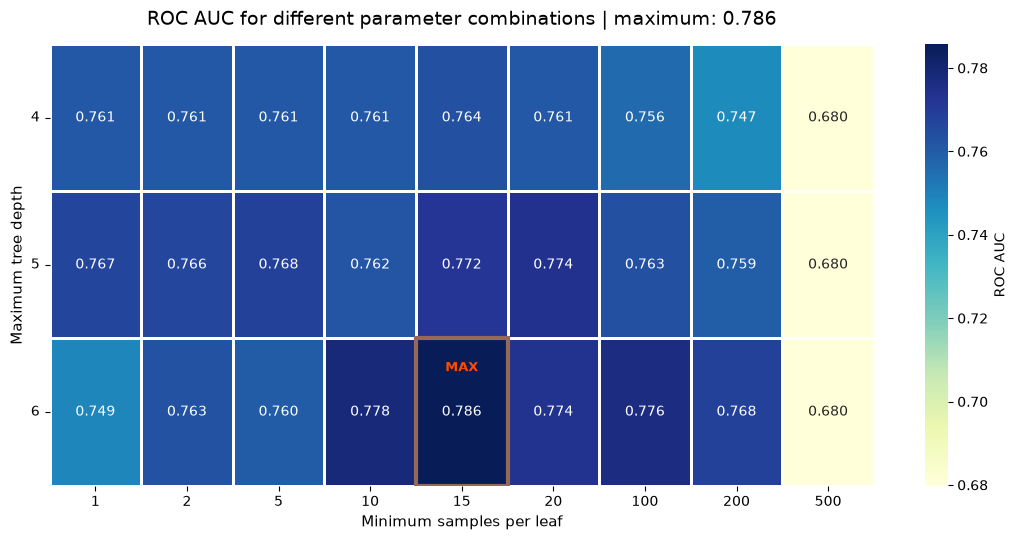

In [38]:
df_scores_pivot = df_scores.pivot(index="max_depth", columns="min_samples_leaf", values="roc_auc")
df_scores_pivot = df_scores_pivot.apply(pd.to_numeric, errors="coerce")

max_position = np.unravel_index(
    np.nanargmax(df_scores_pivot.to_numpy()),
    df_scores_pivot.shape
)
max_row, max_col = max_position
max_value = df_scores_pivot.iloc[max_row, max_col]

plt.figure(figsize=(11, 5.5))
ax = sns.heatmap(
    df_scores_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "ROC AUC"},
    annot_kws={"fontsize": 10}
)

ax.add_patch(
    plt.Rectangle(
        (max_col, max_row),
        1,
        1,
        fill=False,
        edgecolor="#946956",
        linewidth=3
    )
)
ax.text(
    max_col + 0.5,
    max_row + 0.2,
    "MAX",
    ha="center",
    va="center",
    color="#ff4d00",
    fontsize=9,
    fontweight="bold"
)

plt.title(
    f"ROC AUC for different parameter combinations | maximum: {max_value:.3f}",
    fontsize=14,
    pad=14
)
plt.xlabel("Minimum samples per leaf", fontsize=11)
plt.ylabel("Maximum tree depth", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Ensembles and random forest

In [39]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [40]:
y_pred_val = rf.predict_proba(X_val)[:, 1]

In [41]:
roc_auc_score(y_val, y_pred_val)

0.7900692644886296

In [42]:
scores = []
for n in range(10,201,10):
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred_val = rf.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_pred_val)
    scores.append((n, score))
    print(n, score)

10 0.7877412753384515
20 0.7972227604078371
30 0.8124349131772057
40 0.8071462304134073
50 0.8142906444503646
60 0.81147526095275
70 0.8110332760165655
80 0.8230667699983047
90 0.823844784577753
100 0.8175207672374126
110 0.8181383352304377
120 0.8162523310164442
130 0.8198941657988424
140 0.8185016105204524
150 0.8157346637281733
160 0.8166489065413771
170 0.8213957036642368
180 0.8190223051028068
190 0.8201484585018528
200 0.8198638928580079


In [43]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'roc_auc'])
df_scores

,n_estimators,roc_auc
0,10,0.787741
1,20,0.797223
2,30,0.812435
3,40,0.807146
4,50,0.814291
5,60,0.811475
6,70,0.811033
7,80,0.823067
8,90,0.823845
9,100,0.817521


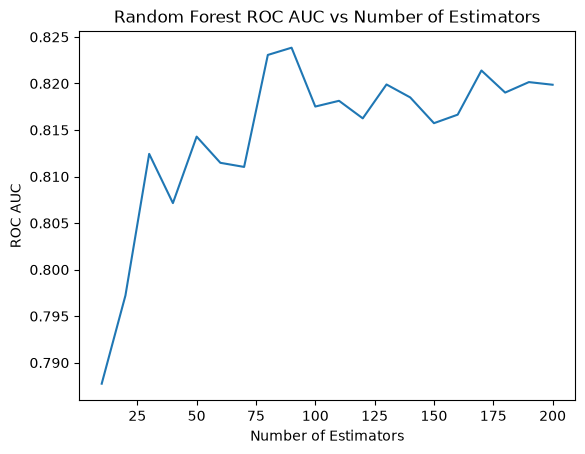

In [44]:
plt.plot(df_scores['n_estimators'], df_scores['roc_auc'])
plt.xlabel('Number of Estimators')
plt.ylabel('ROC AUC')
plt.title('Random Forest ROC AUC vs Number of Estimators')
plt.show()

In [45]:
scores = []
for d in [5, 10, 15]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred_val = rf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_val)
        scores.append((d, n, score))
        print(d, n, score)
df_scores = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'roc_auc'])
df_scores

5 10 0.7876988932212832
5 20 0.7977313458138577
5 30 0.8003045457847957
5 40 0.7997081688503548
5 50 0.7998776973190285
5 60 0.8011673245985809
5 70 0.8022510958804582
5 80 0.803244048339832
5 90 0.8036164055120971
5 100 0.8044519386791311
5 110 0.8066255358310528
5 120 0.8064499527742124
5 130 0.8080544186384443
5 140 0.807019084061902
5 150 0.8072188854714104
5 160 0.8071341212370734
5 170 0.8069645927683999
5 180 0.8072612675885785
5 190 0.8072309946477441
5 200 0.8073520864110824
10 10 0.7913649463563488
10 20 0.8084964035746288
10 30 0.8115842435397544
10 40 0.8178386331161753
10 50 0.8170575912426437
10 60 0.8186560025187086
10 70 0.8202301954421061
10 80 0.8204118330871135
10 90 0.8198427017994235
10 100 0.8211686566079774
10 110 0.8226459761207041
10 120 0.8232272165847279
10 130 0.8245168438642805
10 140 0.824129350221598
10 150 0.8241656777505995
10 160 0.8252433944443098
10 170 0.8246318810394516
10 180 0.8248014095081252
10 190 0.8245350076287811
10 200 0.8249225012714635
1

,max_depth,n_estimators,roc_auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


In [46]:
df_scores_pivot = df_scores.pivot(index='n_estimators', columns='max_depth', values='roc_auc')
df_scores_pivot

max_depth,5,10,15
n_estimators,,,
10,0.787699,0.791365,0.794704
20,0.797731,0.808496,0.808848
30,0.800305,0.811584,0.810128
40,0.799708,0.817839,0.813337
50,0.799878,0.817058,0.813364
60,0.801167,0.818656,0.813101
70,0.802251,0.820230,0.814061
80,0.803244,0.820412,0.814887
90,0.803616,0.819843,0.815420


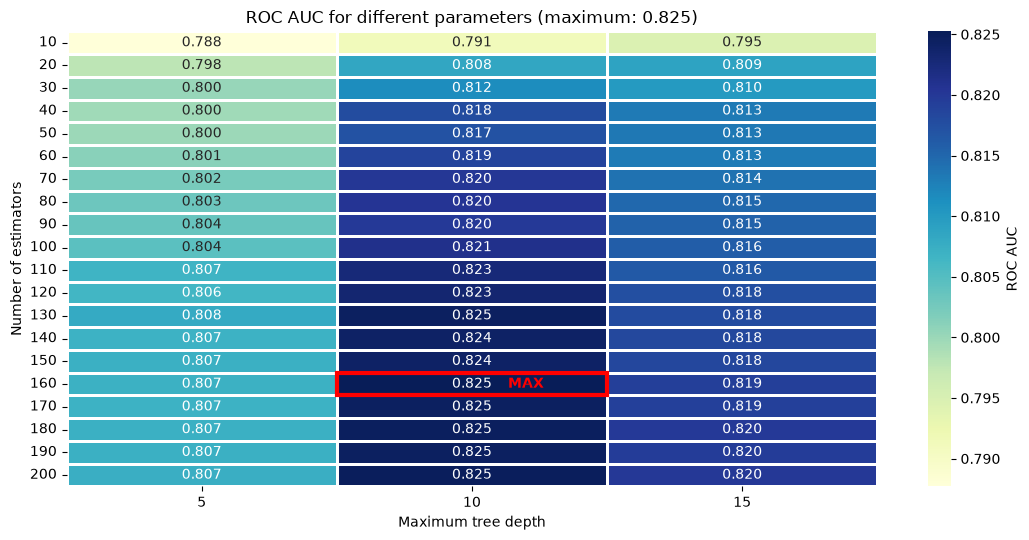

In [47]:
max_position = np.unravel_index(
    np.nanargmax(df_scores_pivot.to_numpy()),
    df_scores_pivot.shape
)
max_row, max_col = max_position
max_value = df_scores_pivot.iloc[max_row, max_col]

plt.figure(figsize=(11, 5.5))
ax = sns.heatmap(
    df_scores_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "ROC AUC"}
)

ax.add_patch(
    plt.Rectangle(
        (max_col, max_row),
        1,
        1,
        fill=False,
        edgecolor="red",
        linewidth=3
    )
)

ax.text(
    max_col + 0.7,
    max_row + 0.5,
    "MAX",
    ha="center",
    va="center",
    color="red",
    fontsize=10,
    fontweight="bold"
)

plt.title(f"ROC AUC for different parameters (maximum: {max_value:.3f})")
plt.xlabel("Maximum tree depth")
plt.ylabel("Number of estimators")
plt.tight_layout()
plt.show()

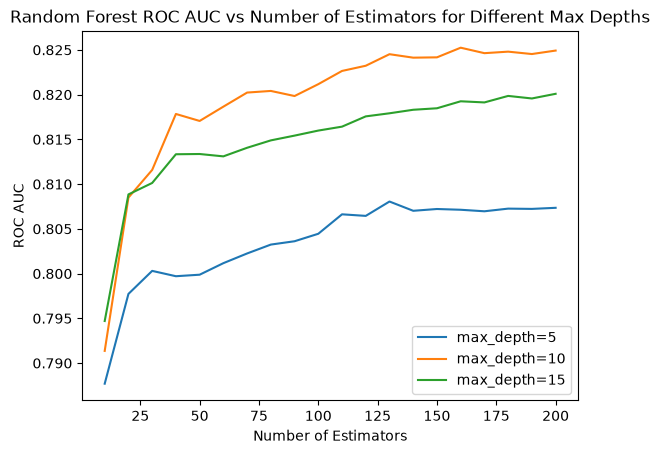

In [48]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores['max_depth'] == d]
    plt.plot(df_subset['n_estimators'], df_subset['roc_auc'], label=f'max_depth={d}')
plt.xlabel('Number of Estimators')
plt.ylabel('ROC AUC')
plt.title('Random Forest ROC AUC vs Number of Estimators for Different Max Depths')
plt.legend()
plt.show()

In [49]:
scores = []
for s in [1, 3, 5, 10, 25, 50]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_leaf=s, random_state=1)
        rf.fit(X_train, y_train)
        y_pred_val = rf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_val)
        scores.append((s, n, score))
        print(s, n, score)
df_scores = pd.DataFrame(scores, columns=['min_samples_leaf', 'n_estimators', 'roc_auc'])
df_scores

1 10 0.7913649463563488
1 20 0.8084964035746288
1 30 0.8115842435397544
1 40 0.8178386331161753
1 50 0.8170575912426437
1 60 0.8186560025187086
1 70 0.8202301954421061
1 80 0.8204118330871135
1 90 0.8198427017994235
1 100 0.8211686566079774
1 110 0.8226459761207041
1 120 0.8232272165847279
1 130 0.8245168438642805
1 140 0.824129350221598
1 150 0.8241656777505995
1 160 0.8252433944443098
1 170 0.8246318810394516
1 180 0.8248014095081252
1 190 0.8245350076287811
1 200 0.8249225012714635
3 10 0.8107577922549707
3 20 0.819806374270422
3 30 0.822530938945533
3 40 0.822101063185682
3 50 0.8229365963527162
3 60 0.8227065220023735
3 70 0.8215379864861592
3 80 0.8226278123562035
3 90 0.8232817078782301
3 100 0.8233361991717324
3 110 0.8234027996415685
3 120 0.8245894989222833
3 130 0.8244139158654429
3 140 0.8250072655058003
3 150 0.8248498462134606
3 160 0.8256551064396599
3 170 0.8249588288004649
3 180 0.8252676127969776
3 190 0.8251465210336393
3 200 0.8246258264512848
5 10 0.812946525877309

,min_samples_leaf,n_estimators,roc_auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058
...,...,...,...
115,50,160,0.805929
116,50,170,0.805172
117,50,180,0.805324
118,50,190,0.805596


In [50]:
df_scores_pivot = df_scores.pivot(index='n_estimators', columns='min_samples_leaf', values='roc_auc')
df_scores_pivot

min_samples_leaf,1,3,5,10,25,50
n_estimators,,,,,,
10,0.791365,0.810758,0.812947,0.809665,0.799260,0.798891
20,0.808496,0.819806,0.814754,0.817548,0.809617,0.805169
30,0.811584,0.822531,0.817802,0.822319,0.812959,0.803562
40,0.817839,0.822101,0.820448,0.822331,0.810283,0.805227
50,0.817058,0.822937,0.821266,0.822380,0.808823,0.805378
60,0.818656,0.822707,0.822573,0.821774,0.810101,0.805469
70,0.820230,0.821538,0.822198,0.819383,0.810942,0.804712
80,0.820412,0.822628,0.822852,0.819703,0.810385,0.804410
90,0.819843,0.823282,0.822470,0.820369,0.810973,0.806226


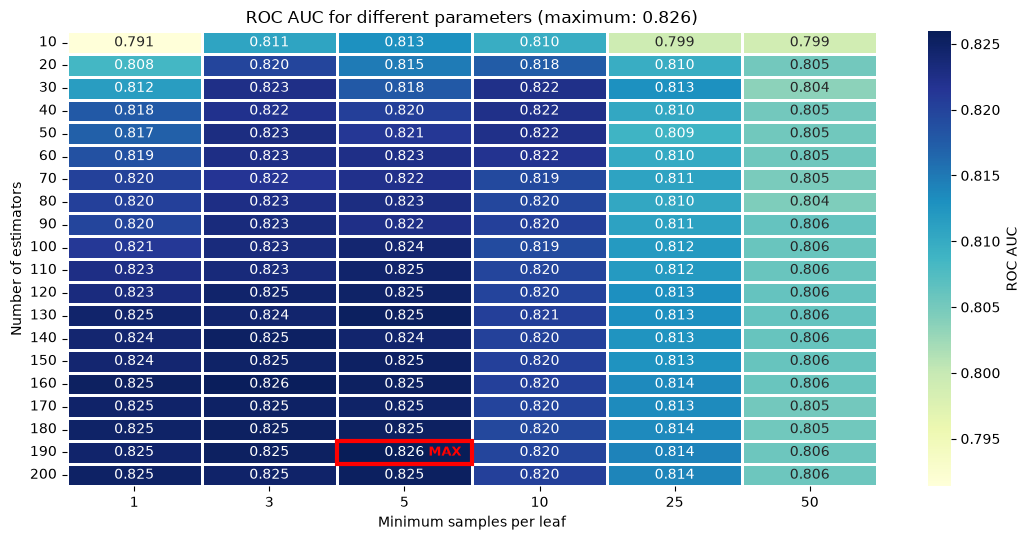

In [51]:
max_position = np.unravel_index(
    np.nanargmax(df_scores_pivot.to_numpy()),
    df_scores_pivot.shape
)
max_row, max_col = max_position
max_value = df_scores_pivot.iloc[max_row, max_col]

plt.figure(figsize=(11, 5.5))
ax = sns.heatmap(
    df_scores_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "ROC AUC"}
)

ax.add_patch(
    plt.Rectangle(
        (max_col, max_row),
        1,
        1,
        fill=False,
        edgecolor="red",
        linewidth=3
    )
)

ax.text(
    max_col + 0.8,
    max_row + 0.5,
    "MAX",
    ha="center",
    va="center",
    color="red",
    fontsize=9,
    fontweight="bold"
)

plt.title(f"ROC AUC for different parameters (maximum: {max_value:.3f})")
plt.xlabel("Minimum samples per leaf")
plt.ylabel("Number of estimators")
plt.tight_layout()
plt.show()

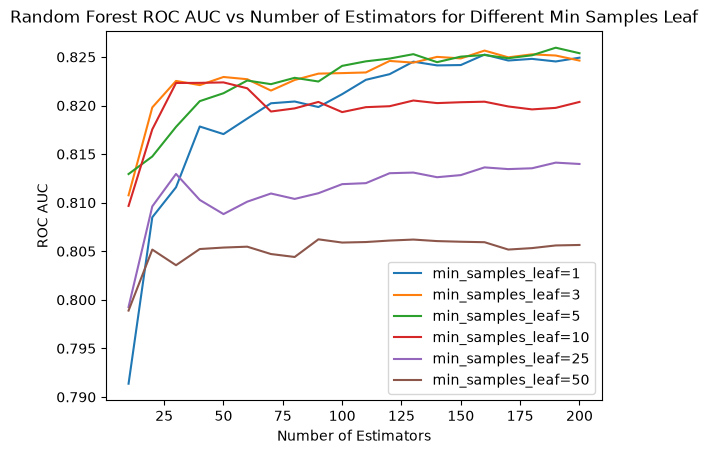

In [52]:
for s in [1, 3, 5, 10, 25, 50]:
    df_subset = df_scores[df_scores['min_samples_leaf'] == s]
    plt.plot(df_subset['n_estimators'], df_subset['roc_auc'], label=f'min_samples_leaf={s}')
plt.xlabel('Number of Estimators')
plt.ylabel('ROC AUC')
plt.title('Random Forest ROC AUC vs Number of Estimators for Different Min Samples Leaf')
plt.legend()
plt.show()

In [53]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=1)
rf.fit(X_train, y_train)
y_pred_val = rf.predict_proba(X_val)[:, 1]
score = roc_auc_score(y_val, y_pred_val)
print(score)

0.8240809135162626


In [54]:
y_pred_train = rf.predict_proba(X_train)[:, 1]
score_train = roc_auc_score(y_train, y_pred_train)
print(score_train)

0.940290687848572


#### Gradient boosting and XGBoost

In [55]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(data=X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(data=X_val, label=y_val, feature_names=features)

In [56]:
features

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [57]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    'eval_metric': 'auc'
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=10)

In [58]:
y_val_pred = model.predict(dval)

In [59]:
roc_auc_score(y_val, y_val_pred)

0.8156256811411687

In [60]:
%%capture output

watchlist = [(dtrain, 'train'), (dval, 'eval')]
model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=201, verbose_eval=5, evals=watchlist)

In [61]:
print(output)

[0]	train-auc:0.86632	eval-auc:0.77998
[5]	train-auc:0.93359	eval-auc:0.81150
[10]	train-auc:0.95391	eval-auc:0.82002
[15]	train-auc:0.97087	eval-auc:0.82220
[20]	train-auc:0.97677	eval-auc:0.82239
[25]	train-auc:0.98440	eval-auc:0.82074
[30]	train-auc:0.98805	eval-auc:0.82061
[35]	train-auc:0.99239	eval-auc:0.81804
[40]	train-auc:0.99474	eval-auc:0.81732
[45]	train-auc:0.99627	eval-auc:0.81413
[50]	train-auc:0.99753	eval-auc:0.81320
[55]	train-auc:0.99811	eval-auc:0.81140
[60]	train-auc:0.99893	eval-auc:0.80818
[65]	train-auc:0.99924	eval-auc:0.80696
[70]	train-auc:0.99955	eval-auc:0.80710
[75]	train-auc:0.99979	eval-auc:0.80802
[80]	train-auc:0.99987	eval-auc:0.80813
[85]	train-auc:0.99993	eval-auc:0.80761
[90]	train-auc:0.99995	eval-auc:0.80782
[95]	train-auc:0.99997	eval-auc:0.80870
[100]	train-auc:0.99999	eval-auc:0.80839
[105]	train-auc:1.00000	eval-auc:0.80735
[110]	train-auc:1.00000	eval-auc:0.80730
[115]	train-auc:1.00000	eval-auc:0.80779
[120]	train-auc:1.00000	eval-auc:0.805

In [62]:
s = output.stdout

In [63]:
def parse_xgb_output(s):
    """
    Parse the output of an XGBoost training log and return a DataFrame with iteration, train_auc, and eval_auc columns.
    
    Parameters:
    s (str): The XGBoost training log as a string.

    Returns:
    pd.DataFrame: A DataFrame containing the parsed information.
    """
    log_pattern = re.compile(
        r"\[(?P<iteration>\d+)\]\s+"
        r"train-auc:(?P<train_auc>[0-9.]+)\s+"
        r"eval-auc:(?P<eval_auc>[0-9.]+)"
    )

    output_df = pd.DataFrame(
        [match.groupdict() for match in log_pattern.finditer(s)]
    )

    output_df = output_df.astype({
        'iteration': int,
        'train_auc': float,
        'eval_auc': float,
    })

    return output_df

In [64]:
output_df = parse_xgb_output(s)

In [65]:
output_df

,iteration,train_auc,eval_auc
0,0,0.86632,0.77998
1,5,0.93359,0.81150
2,10,0.95391,0.82002
3,15,0.97087,0.82220
4,20,0.97677,0.82239
5,25,0.98440,0.82074
6,30,0.98805,0.82061
7,35,0.99239,0.81804
8,40,0.99474,0.81732
9,45,0.99627,0.81413


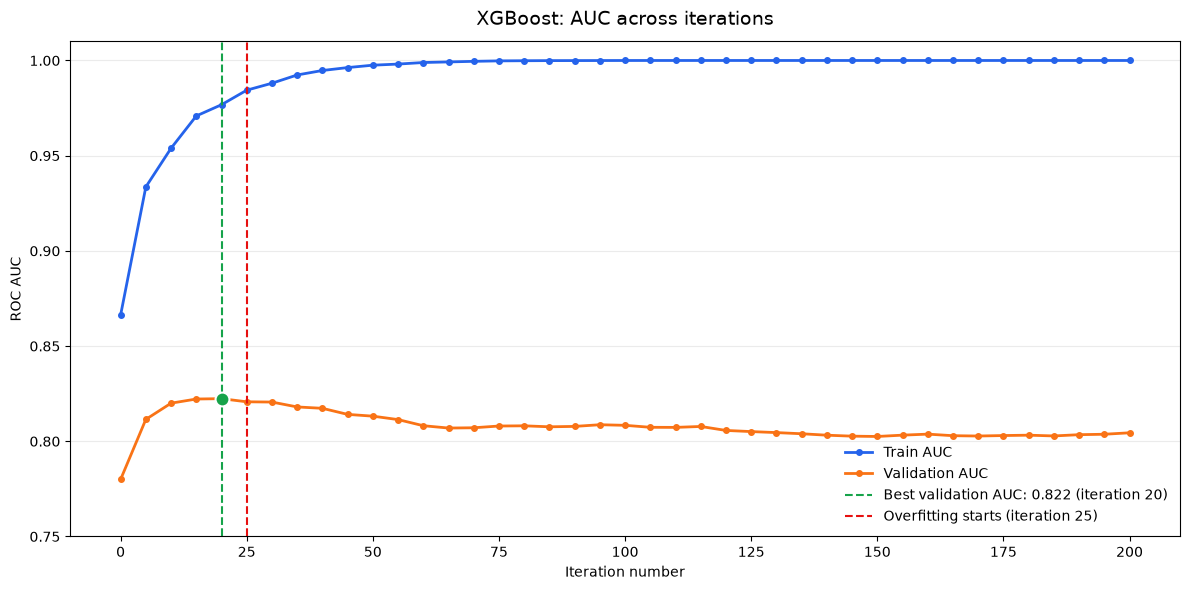

In [66]:
best_position = output_df['eval_auc'].idxmax()
best_row = output_df.loc[best_position]

if best_position < output_df.index[-1]:
    overfitting_row = output_df.iloc[output_df.index.get_loc(best_position) + 1]
else:
    overfitting_row = best_row

plt.figure(figsize=(12, 6))
plt.plot(
    output_df['iteration'],
    output_df['train_auc'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Train AUC',
    color='#2563eb',
)
plt.plot(
    output_df['iteration'],
    output_df['eval_auc'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Validation AUC',
    color='#f97316',
)

plt.axvline(
    best_row['iteration'],
    color='#16a34a',
    linestyle='--',
    linewidth=1.5,
    label=f"Best validation AUC: {best_row['eval_auc']:.3f} "
          f"(iteration {int(best_row['iteration'])})",
)
plt.axvline(
    overfitting_row['iteration'],
    color='#e61010',
    linestyle='--',
    linewidth=1.5,
    label=f"Overfitting starts (iteration {int(overfitting_row['iteration'])})",
)
plt.scatter(
    best_row['iteration'],
    best_row['eval_auc'],
    color='#16a34a',
    s=100,
    zorder=5,
    edgecolor='white',
    linewidth=1.5,
)

plt.title('XGBoost: AUC across iterations', fontsize=14, pad=12)
plt.xlabel('Iteration number')
plt.ylabel('ROC AUC')
plt.ylim(0.75, 1.01)
plt.grid(axis='y', alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

#### XGBoost parameter tuning

##### ETA

In [67]:
eta_list = [0.3, 1.0, 0.1, 0.05, 0.01]
eta_results = {}


In [68]:
for eta in eta_list:
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
        'eval_metric': 'auc'
    }

    evals_result = {}
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=201,
        verbose_eval=5,
        evals=watchlist,
        evals_result=evals_result,
    )

    eta_results[eta] = pd.DataFrame({
        'iteration': range(len(evals_result['train']['auc'])),
        'train_auc': evals_result['train']['auc'],
        'eval_auc': evals_result['eval']['auc'],
    })

[0]	train-auc:0.86632	eval-auc:0.77998
[5]	train-auc:0.93359	eval-auc:0.81150
[10]	train-auc:0.95391	eval-auc:0.82002
[15]	train-auc:0.97087	eval-auc:0.82220
[20]	train-auc:0.97677	eval-auc:0.82239
[25]	train-auc:0.98440	eval-auc:0.82074
[30]	train-auc:0.98805	eval-auc:0.82061
[35]	train-auc:0.99239	eval-auc:0.81804
[40]	train-auc:0.99474	eval-auc:0.81732
[45]	train-auc:0.99627	eval-auc:0.81413
[50]	train-auc:0.99753	eval-auc:0.81320
[55]	train-auc:0.99811	eval-auc:0.81140
[60]	train-auc:0.99893	eval-auc:0.80818
[65]	train-auc:0.99924	eval-auc:0.80696
[70]	train-auc:0.99955	eval-auc:0.80710
[75]	train-auc:0.99979	eval-auc:0.80802
[80]	train-auc:0.99987	eval-auc:0.80813
[85]	train-auc:0.99993	eval-auc:0.80761
[90]	train-auc:0.99995	eval-auc:0.80782
[95]	train-auc:0.99997	eval-auc:0.80870
[100]	train-auc:0.99999	eval-auc:0.80839
[105]	train-auc:1.00000	eval-auc:0.80735
[110]	train-auc:1.00000	eval-auc:0.80730
[115]	train-auc:1.00000	eval-auc:0.80779
[120]	train-auc:1.00000	eval-auc:0.805

In [69]:
max_auc_gap = 0.2

best_eta_no_gap = None
best_iteration_no_gap = None
best_auc_no_gap = -np.inf

best_eta_with_gap = None
best_iteration_with_gap = None
best_auc_with_gap = -np.inf
best_gap_with_gap = None

for eta, output_df in eta_results.items():
    best_idx = output_df['eval_auc'].idxmax()
    best_row = output_df.loc[best_idx]

    best_iteration = int(best_row['iteration'])
    best_auc = best_row['eval_auc']
    best_train_auc = best_row['train_auc']
    auc_gap = best_train_auc - best_auc
    output_every_5 = output_df.iloc[::5]

    display(f"Results for eta = {eta}")
    display(output_every_5)
    display(
        f"Best iteration for eta = {eta} is {best_iteration}, "
        f"with validation AUC = {best_auc:.3f}, "
        f"train AUC = {best_train_auc:.3f}, "
        f"AUC gap = {auc_gap:.3f}"
    )

    if best_auc > best_auc_no_gap:
        best_eta_no_gap = eta
        best_iteration_no_gap = best_iteration
        best_auc_no_gap = best_auc

    if auc_gap <= max_auc_gap and best_auc > best_auc_with_gap:
        best_eta_with_gap = eta
        best_iteration_with_gap = best_iteration
        best_auc_with_gap = best_auc
        best_gap_with_gap = auc_gap

display(
    f"Best model without AUC gap restriction: "
    f"eta = {best_eta_no_gap}, "
    f"iteration = {best_iteration_no_gap}, "
    f"validation AUC = {best_auc_no_gap:.3f}"
)

if best_eta_with_gap is not None:
    display(
        f"Best model with AUC gap <= {max_auc_gap:.2f}: "
        f"eta = {best_eta_with_gap}, "
        f"iteration = {best_iteration_with_gap}, "
        f"validation AUC = {best_auc_with_gap:.3f}, "
        f"AUC gap = {best_gap_with_gap:.3f}"
    )
else:
    display(f"No model met the AUC gap <= {max_auc_gap:.2f} condition.")

'Results for eta = 0.3'

,iteration,train_auc,eval_auc
0,0,0.866320,0.779979
5,5,0.933595,0.811496
10,10,0.953907,0.820018
15,15,0.970873,0.822198
20,20,0.976775,0.822392
25,25,0.984399,0.820745
30,30,0.988049,0.820606
35,35,0.992390,0.818038
40,40,0.994743,0.817324
45,45,0.996271,0.814133


'Best iteration for eta = 0.3 is 22, with validation AUC = 0.823, train AUC = 0.979, AUC gap = 0.156'

'Results for eta = 1.0'

,iteration,train_auc,eval_auc
0,0,0.866320,0.779979
5,5,0.961380,0.793508
10,10,0.987568,0.780524
15,15,0.996328,0.784339
20,20,0.999179,0.785441
25,25,0.999946,0.785889
30,30,1.000000,0.787529
35,35,1.000000,0.787039
40,40,1.000000,0.789673
45,45,1.000000,0.794413


'Best iteration for eta = 1.0 is 196, with validation AUC = 0.800, train AUC = 1.000, AUC gap = 0.200'

'Results for eta = 0.1'

,iteration,train_auc,eval_auc
0,0,0.866320,0.779979
5,5,0.904530,0.792685
10,10,0.920257,0.804579
15,15,0.929985,0.810758
20,20,0.938343,0.813749
25,25,0.947129,0.812853
30,30,0.951460,0.815604
35,35,0.958988,0.818190
40,40,0.962739,0.818202
45,45,0.966639,0.820206


'Best iteration for eta = 0.1 is 71, with validation AUC = 0.825, train AUC = 0.982, AUC gap = 0.157'

'Results for eta = 0.05'

,iteration,train_auc,eval_auc
0,0,0.866320,0.779979
5,5,0.887053,0.796296
10,10,0.901856,0.793817
15,15,0.909957,0.800759
20,20,0.916612,0.806268
25,25,0.922817,0.805993
30,30,0.929306,0.809480
35,35,0.935095,0.812789
40,40,0.939957,0.815393
45,45,0.944289,0.815598


'Best iteration for eta = 0.05 is 189, with validation AUC = 0.828, train AUC = 0.988, AUC gap = 0.160'

'Results for eta = 0.01'

,iteration,train_auc,eval_auc
0,0,0.866320,0.779979
5,5,0.870069,0.778208
10,10,0.872083,0.778381
15,15,0.873815,0.782767
20,20,0.875841,0.787193
25,25,0.885949,0.795706
30,30,0.893294,0.800005
35,35,0.896416,0.799714
40,40,0.898806,0.798658
45,45,0.900658,0.796899


'Best iteration for eta = 0.01 is 199, with validation AUC = 0.815, train AUC = 0.938, AUC gap = 0.123'

'Best model without AUC gap restriction: eta = 0.05, iteration = 189, validation AUC = 0.828'

'Best model with AUC gap <= 0.20: eta = 0.05, iteration = 189, validation AUC = 0.828, AUC gap = 0.160'

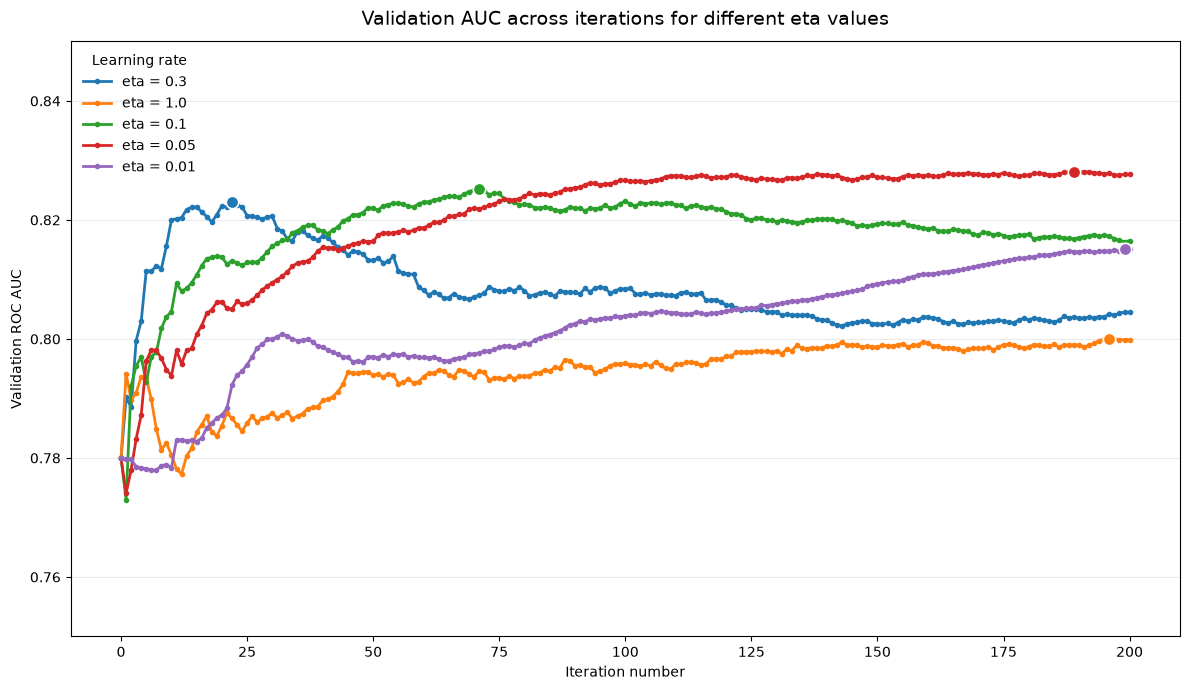

In [70]:
plt.figure(figsize=(12, 7))

for eta, output_df in eta_results.items():
    plt.plot(
        output_df['iteration'],
        output_df['eval_auc'],
        marker='o',
        markersize=3,
        linewidth=2,
        label=f'eta = {eta}',
    )

    best_idx = output_df['eval_auc'].idxmax()
    best_row = output_df.loc[best_idx]
    plt.scatter(
        best_row['iteration'],
        best_row['eval_auc'],
        s=80,
        zorder=5,
        edgecolor='white',
        linewidth=1.2,
    )

plt.title('Validation AUC across iterations for different eta values', fontsize=14, pad=12)
plt.xlabel('Iteration number')
plt.ylabel('Validation ROC AUC')
plt.ylim(0.75, 0.85)
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Learning rate', frameon=False)
plt.tight_layout()
plt.show()

##### Max Depth

In [78]:
def tune_xgb_param(
    param_name,
    param_values,
    dtrain,
    watchlist,
    base_params=None,
    num_boost_round=201,
    max_auc_gap=0.2,
    ylim=None,
    verbose=True,
    plot=True,
):
    """
    Train XGBoost for every value of a single parameter and compare validation AUC.

    Returns a dict mapping each parameter value to a DataFrame with
    iteration, train_auc and eval_auc columns.
    """
    default_params = {
        'eta': 0.1,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
        'eval_metric': 'auc',
    }
    if base_params:
        default_params.update(base_params)

    results = {}
    for value in param_values:
        xgb_params = {**default_params, param_name: value}

        evals_result = {}
        xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=num_boost_round,
            verbose_eval=False,
            evals=watchlist,
            evals_result=evals_result,
        )

        results[value] = pd.DataFrame({
            'iteration': range(len(evals_result['train']['auc'])),
            'train_auc': evals_result['train']['auc'],
            'eval_auc': evals_result['eval']['auc'],
        })

    summarize_tuning_results(results, param_name, max_auc_gap=max_auc_gap, verbose=verbose)

    if plot:
        plot_tuning_results(results, param_name, ylim=ylim)

    return results


def summarize_tuning_results(results, param_name, max_auc_gap=0.2, verbose=True):
    """Report the best value of the tuned parameter, with and without an AUC gap restriction."""
    best_no_gap = None
    best_with_gap = None

    for value, output_df in results.items():
        best_row = output_df.loc[output_df['eval_auc'].idxmax()]

        candidate = {
            'value': value,
            'iteration': int(best_row['iteration']),
            'eval_auc': best_row['eval_auc'],
            'train_auc': best_row['train_auc'],
            'auc_gap': best_row['train_auc'] - best_row['eval_auc'],
        }

        if verbose:
            display(f"Results for {param_name} = {value}")
            display(output_df.iloc[::5])
            display(
                f"Best iteration for {param_name} = {value} is {candidate['iteration']}, "
                f"with validation AUC = {candidate['eval_auc']:.3f}, "
                f"train AUC = {candidate['train_auc']:.3f}, "
                f"AUC gap = {candidate['auc_gap']:.3f}"
            )

        if best_no_gap is None or candidate['eval_auc'] > best_no_gap['eval_auc']:
            best_no_gap = candidate

        if candidate['auc_gap'] <= max_auc_gap:
            if best_with_gap is None or candidate['eval_auc'] > best_with_gap['eval_auc']:
                best_with_gap = candidate

    display(
        f"Best model without AUC gap restriction: "
        f"{param_name} = {best_no_gap['value']}, "
        f"iteration = {best_no_gap['iteration']}, "
        f"validation AUC = {best_no_gap['eval_auc']:.3f}"
    )

    if best_with_gap is not None:
        display(
            f"Best model with AUC gap <= {max_auc_gap:.2f}: "
            f"{param_name} = {best_with_gap['value']}, "
            f"iteration = {best_with_gap['iteration']}, "
            f"validation AUC = {best_with_gap['eval_auc']:.3f}, "
            f"AUC gap = {best_with_gap['auc_gap']:.3f}"
        )
    else:
        display(f"No model met the AUC gap <= {max_auc_gap:.2f} condition.")

    return best_no_gap, best_with_gap


def plot_tuning_results(results, param_name, ylim=None, padding=0.05):
    """
    Plot validation AUC across iterations for every value of the tuned parameter.

    When ylim is None the y axis is scaled to the observed validation AUC range.
    """
    plt.figure(figsize=(12, 7))

    for value, output_df in results.items():
        plt.plot(
            output_df['iteration'],
            output_df['eval_auc'],
            marker='o',
            markersize=3,
            linewidth=2,
            label=f'{param_name} = {value}',
        )

        best_row = output_df.loc[output_df['eval_auc'].idxmax()]
        plt.scatter(
            best_row['iteration'],
            best_row['eval_auc'],
            s=80,
            zorder=5,
            edgecolor='white',
            linewidth=1.2,
        )

    if ylim is None:
        all_auc = np.concatenate([df['eval_auc'].to_numpy() for df in results.values()])
        low, high = all_auc.min(), all_auc.max()
        margin = max((high - low) * padding, 0.001)
        ylim = (low - margin, min(high + margin, 1.0))

    plt.title(f'Validation AUC across iterations for different {param_name} values', fontsize=14, pad=12)
    plt.xlabel('Iteration number')
    plt.ylabel('Validation ROC AUC')
    plt.ylim(*ylim)
    plt.grid(axis='y', alpha=0.25)
    plt.legend(title=param_name, frameon=False)
    plt.tight_layout()
    plt.show()


'Results for max_depth = 3'

,iteration,train_auc,eval_auc
0,0,0.776102,0.738908
5,5,0.831482,0.775124
10,10,0.849592,0.790360
15,15,0.860424,0.803741
20,20,0.869232,0.812002
25,25,0.875509,0.814336
30,30,0.881500,0.817790
35,35,0.885894,0.821078
40,40,0.889987,0.823088
45,45,0.893702,0.824596


'Best iteration for max_depth = 3 is 178, with validation AUC = 0.835, train AUC = 0.939, AUC gap = 0.104'

'Results for max_depth = 4'

,iteration,train_auc,eval_auc
0,0,0.816653,0.760008
5,5,0.853046,0.791389
10,10,0.867082,0.802805
15,15,0.880865,0.808917
20,20,0.890733,0.813685
25,25,0.897250,0.816737
30,30,0.903576,0.818580
35,35,0.909837,0.819307
40,40,0.913901,0.821532
45,45,0.918718,0.822062


'Best iteration for max_depth = 4 is 100, with validation AUC = 0.829, train AUC = 0.948, AUC gap = 0.119'

'Results for max_depth = 10'

,iteration,train_auc,eval_auc
0,0,0.918614,0.774000
5,5,0.964541,0.785262
10,10,0.980281,0.794465
15,15,0.988177,0.802648
20,20,0.993129,0.805999
25,25,0.996342,0.808067
30,30,0.997661,0.810301
35,35,0.998740,0.811717
40,40,0.999194,0.810682
45,45,0.999527,0.812704


'Best iteration for max_depth = 10 is 99, with validation AUC = 0.818, train AUC = 1.000, AUC gap = 0.182'

'Results for max_depth = 15'

,iteration,train_auc,eval_auc
0,0,0.928134,0.768575
5,5,0.976672,0.785771
10,10,0.987929,0.792543
15,15,0.994650,0.799206
20,20,0.997704,0.800389
25,25,0.999057,0.802611
30,30,0.999598,0.802672
35,35,0.999837,0.803677
40,40,0.999936,0.804500
45,45,0.999974,0.806129


'Best iteration for max_depth = 15 is 93, with validation AUC = 0.809, train AUC = 1.000, AUC gap = 0.191'

'Results for max_depth = 20'

,iteration,train_auc,eval_auc
0,0,0.928278,0.768612
5,5,0.976734,0.785692
10,10,0.987970,0.791967
15,15,0.994574,0.797668
20,20,0.997438,0.800056
25,25,0.998954,0.800165
30,30,0.999611,0.800977
35,35,0.999859,0.803368
40,40,0.999937,0.807455
45,45,0.999977,0.807746


'Best iteration for max_depth = 20 is 87, with validation AUC = 0.812, train AUC = 1.000, AUC gap = 0.188'

'Results for max_depth = 50'

,iteration,train_auc,eval_auc
0,0,0.928278,0.768612
5,5,0.976734,0.785692
10,10,0.987970,0.791967
15,15,0.994574,0.797668
20,20,0.997438,0.800056
25,25,0.998954,0.800165
30,30,0.999611,0.800977
35,35,0.999858,0.803053
40,40,0.999938,0.807443
45,45,0.999982,0.808424


'Best iteration for max_depth = 50 is 66, with validation AUC = 0.812, train AUC = 1.000, AUC gap = 0.188'

'Results for max_depth = 100'

,iteration,train_auc,eval_auc
0,0,0.928278,0.768612
5,5,0.976734,0.785692
10,10,0.987970,0.791967
15,15,0.994574,0.797668
20,20,0.997438,0.800056
25,25,0.998954,0.800165
30,30,0.999611,0.800977
35,35,0.999858,0.803053
40,40,0.999938,0.807443
45,45,0.999982,0.808424


'Best iteration for max_depth = 100 is 66, with validation AUC = 0.812, train AUC = 1.000, AUC gap = 0.188'

'Best model without AUC gap restriction: max_depth = 3, iteration = 178, validation AUC = 0.835'

'Best model with AUC gap <= 0.20: max_depth = 3, iteration = 178, validation AUC = 0.835, AUC gap = 0.104'

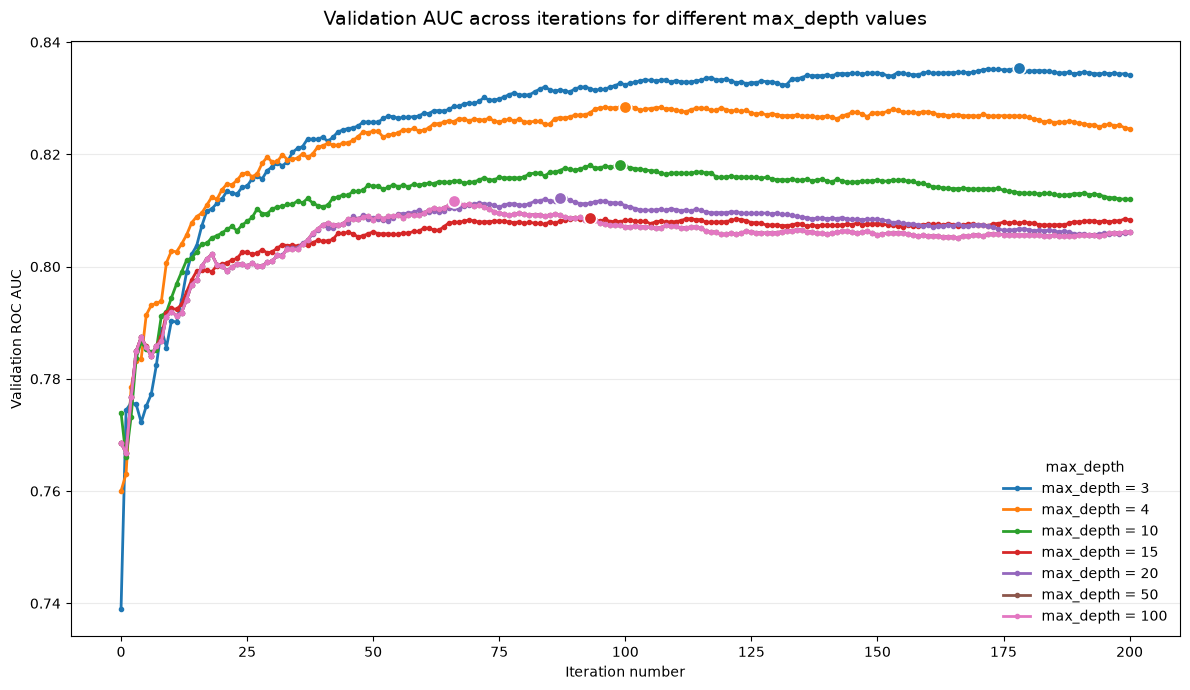

In [83]:
max_depth_results = tune_xgb_param(
    'max_depth',
    [3, 4, 10, 15, 20, 50, 100],
    dtrain,
    watchlist,
    base_params={'eta': 0.1}
    )


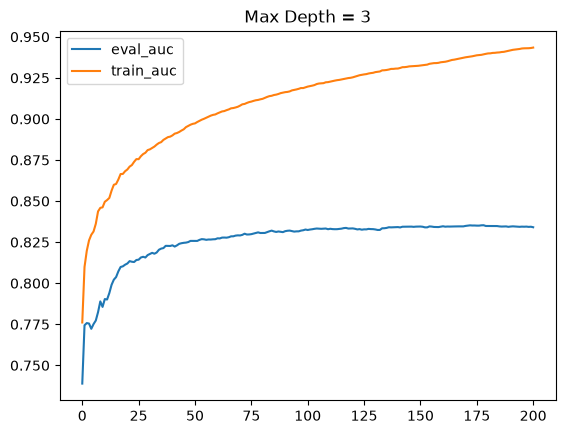

In [75]:
plt.plot(max_depth_results[3]['iteration'], max_depth_results[3]['eval_auc'], label='eval_auc')
plt.plot(max_depth_results[3]['iteration'], max_depth_results[3]['train_auc'], label='train_auc')
plt.title('Max Depth = 3')
plt.legend()
plt.show()

'Results for min_child_weight = 1'

,iteration,train_auc,eval_auc
0,0,0.776102,0.738908
5,5,0.831482,0.775124
10,10,0.849592,0.790360
15,15,0.860424,0.803741
20,20,0.869232,0.812002
25,25,0.875509,0.814336
30,30,0.881500,0.817790
35,35,0.885894,0.821078
40,40,0.889987,0.823088
45,45,0.893702,0.824596


'Best iteration for min_child_weight = 1 is 178, with validation AUC = 0.835, train AUC = 0.939, AUC gap = 0.104'

'Results for min_child_weight = 5'

,iteration,train_auc,eval_auc
0,0,0.774243,0.735705
5,5,0.829559,0.772796
10,10,0.846246,0.786219
15,15,0.858194,0.803071
20,20,0.867893,0.810591
25,25,0.873818,0.815716
30,30,0.880405,0.817363
35,35,0.884371,0.819640
40,40,0.886944,0.820920
45,45,0.890290,0.823006


'Best iteration for min_child_weight = 5 is 125, with validation AUC = 0.834, train AUC = 0.920, AUC gap = 0.086'

'Results for min_child_weight = 10'

,iteration,train_auc,eval_auc
0,0,0.774243,0.735705
5,5,0.829930,0.773038
10,10,0.846350,0.785383
15,15,0.857674,0.803250
20,20,0.867276,0.809828
25,25,0.872236,0.813718
30,30,0.878595,0.817599
35,35,0.881944,0.819691
40,40,0.886021,0.822319
45,45,0.888152,0.823978


'Best iteration for min_child_weight = 10 is 144, with validation AUC = 0.836, train AUC = 0.915, AUC gap = 0.079'

'Results for min_child_weight = 30'

,iteration,train_auc,eval_auc
0,0,0.764551,0.733686
5,5,0.827261,0.775408
10,10,0.844901,0.793675
15,15,0.854942,0.803483
20,20,0.862115,0.811036
25,25,0.868452,0.815014
30,30,0.871419,0.817790
35,35,0.873683,0.820666
40,40,0.877356,0.823987
45,45,0.879190,0.824414


'Best iteration for min_child_weight = 30 is 158, with validation AUC = 0.837, train AUC = 0.900, AUC gap = 0.063'

'Results for min_child_weight = 50'

,iteration,train_auc,eval_auc
0,0,0.761521,0.728467
5,5,0.816608,0.771833
10,10,0.838140,0.792645
15,15,0.847519,0.803744
20,20,0.856298,0.810458
25,25,0.860904,0.813168
30,30,0.864465,0.817439
35,35,0.868042,0.819277
40,40,0.870649,0.821820
45,45,0.872926,0.822864


'Best iteration for min_child_weight = 50 is 176, with validation AUC = 0.835, train AUC = 0.892, AUC gap = 0.057'

'Best model without AUC gap restriction: min_child_weight = 30, iteration = 158, validation AUC = 0.837'

'Best model with AUC gap <= 0.20: min_child_weight = 30, iteration = 158, validation AUC = 0.837, AUC gap = 0.063'

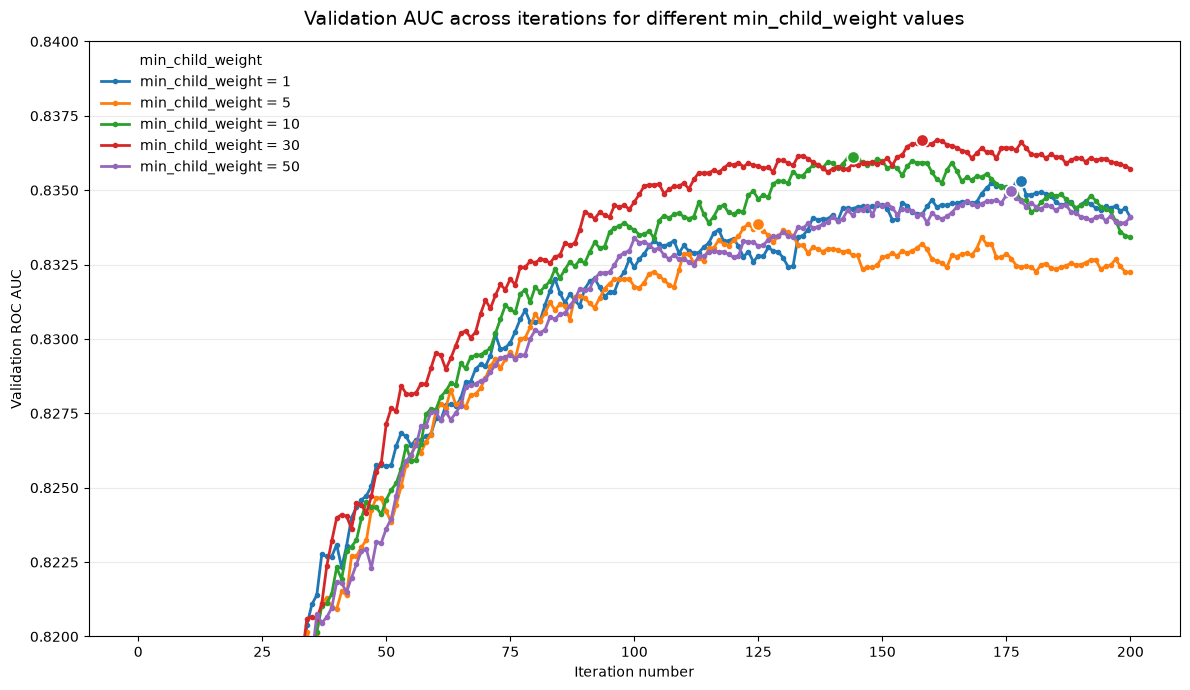

In [84]:
min_child_weight_results = tune_xgb_param(
    'min_child_weight',
    [1, 5, 10, 30, 50],
    dtrain,
    watchlist,
    base_params={'eta': 0.1, 'max_depth': 3},
    ylim = (0.82, 0.84)

)

In [ ]:
xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': 30,
        'objective': 'binary:logistic',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
        'eval_metric': 'auc'
    }

evals_result = {}
model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=201,
    verbose_eval=5,
    evals=watchlist,
    evals_result=evals_result,
)

eta_results[eta] = pd.DataFrame({
        'iteration': range(len(evals_result['train']['auc'])),
        'train_auc': evals_result['train']['auc'],
        'eval_auc': evals_result['eval']['auc'],
    })

[0]	train-auc:0.76455	eval-auc:0.73369
[5]	train-auc:0.82726	eval-auc:0.77541
[10]	train-auc:0.84490	eval-auc:0.79367
[15]	train-auc:0.85494	eval-auc:0.80348
[20]	train-auc:0.86212	eval-auc:0.81104
[25]	train-auc:0.86845	eval-auc:0.81501
[30]	train-auc:0.87142	eval-auc:0.81779
[35]	train-auc:0.87368	eval-auc:0.82067
[40]	train-auc:0.87736	eval-auc:0.82399
[45]	train-auc:0.87919	eval-auc:0.82441
[50]	train-auc:0.88194	eval-auc:0.82715
[55]	train-auc:0.88292	eval-auc:0.82813
[60]	train-auc:0.88469	eval-auc:0.82954
[65]	train-auc:0.88587	eval-auc:0.83019
[70]	train-auc:0.88737	eval-auc:0.83130
[75]	train-auc:0.88840	eval-auc:0.83202
[80]	train-auc:0.88931	eval-auc:0.83256
[85]	train-auc:0.89051	eval-auc:0.83281
[90]	train-auc:0.89150	eval-auc:0.83428
[95]	train-auc:0.89231	eval-auc:0.83409
[100]	train-auc:0.89286	eval-auc:0.83460
[105]	train-auc:0.89363	eval-auc:0.83520
[110]	train-auc:0.89448	eval-auc:0.83524
[115]	train-auc:0.89508	eval-auc:0.83558
[120]	train-auc:0.89575	eval-auc:0.835

In [88]:
best_eta, best_row = max(
    (
        (eta, results.loc[results['eval_auc'].idxmax()])
        for eta, results in eta_results.items()
    ),
    key=lambda item: item[1]['eval_auc']
)

print(f"Best iteration: {int(best_row['iteration'])}")
print(f"Validation AUC: {best_row['eval_auc']:.4f}")

Best iteration: 158
Validation AUC: 0.8367
